In [25]:
import requests 
from bs4 import BeautifulSoup
import pandas as pd
import mplsoccer
import matplotlib.font_manager as fm
import matplotlib.patheffects as path_effects
import numpy as np
from PIL import Image

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import gaussian_filter

from mplsoccer import Pitch, VerticalPitch, FontManager, Sbopen

In [26]:

headers = {
    'authority': 'api.sofascore.com',
    'accept': '*/*',
    'accept-language': 'pt-BR,pt;q=0.6',
    'cache-control': 'max-age=0',
    'origin': 'https://www.sofascore.com',
    'referer': 'https://www.sofascore.com/',
    'sec-ch-ua': '"Not A(Brand";v="99", "Brave";v="121", "Chromium";v="121"',
    'sec-ch-ua-mobile': '?0',
    'sec-ch-ua-platform': '"Windows"',
    'sec-fetch-dest': 'empty',
    'sec-fetch-mode': 'cors',
    'sec-fetch-site': 'same-site',
    'sec-gpc': '1',
    'user-agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/121.0.0.0 Safari/537.36',
}



In [27]:
# Função para normalizar os dados aninhados
def normalize_json(dados_json):
    normalized_data = {}
    
    # Nível 1
    for key, value in dados_json.items():
        if isinstance(value, dict):
            # Nível 2
            for sub_key, sub_value in value.items():
                normalized_data[f"{key}_{sub_key}"] = sub_value
        else:
            normalized_data[key] = value
    
    return normalized_data



In [29]:
stats_data = requests.get('https://api.sofascore.com/api/v1/event/14771344/statistics', headers=headers)
stats_json = stats_data.json()  # Obtenha o JSON da resposta

In [31]:
all_statistics = stats_json['statistics'][0]
tempo_1 = stats_json['statistics'][1]
tempo_2 = stats_json['statistics'][2]

In [32]:
data = stats_json['statistics'][0]['groups']

In [34]:
# Função recursiva para extrair os pares chave-valor
def flatten_dict(d, parent_key='', sep='_'):
    items = []
    for k, v in d.items():
        new_key = f'{parent_key}{sep}{k}' if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        elif isinstance(v, list):
            for i, item in enumerate(v):
                items.extend(flatten_dict(item, f'{new_key}_{i}', sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)

# Lista para armazenar as linhas
rows = []

# Itera sobre os grupos de estatísticas
for group in data:
    # Primeiro, transforma o dicionário do grupo em uma única linha
    flattened_group = flatten_dict(group)
    
    # Adiciona a linha ao DataFrame
    rows.append(flattened_group)

# Cria o DataFrame com as linhas extraídas
df = pd.DataFrame(rows)

# Exibe o DataFrame
print(df)

        groupName statisticsItems_0_name statisticsItems_0_home  \
0  Match overview        Ball possession                    64%   
1           Shots            Total shots                     28   
2          Attack     Big chances scored                      4   
3          Passes        Accurate passes                    349   
4           Duels                  Duels                    51%   
5       Defending            Tackles won                    90%   
6     Goalkeeping            Total saves                      1   

  statisticsItems_0_away  statisticsItems_0_compareCode  \
0                    36%                              1   
1                      8                              1   
2                      0                              1   
3                    156                              1   
4                    49%                              1   
5                    50%                              1   
6                      4                          

In [35]:
df

,groupName,statisticsItems_0_name,statisticsItems_0_home,statisticsItems_0_away,statisticsItems_0_compareCode,statisticsItems_0_statisticsType,statisticsItems_0_valueType,statisticsItems_0_homeValue,statisticsItems_0_awayValue,statisticsItems_0_renderType,...,statisticsItems_3_homeTotal,statisticsItems_3_awayTotal,statisticsItems_4_homeTotal,statisticsItems_4_awayTotal,statisticsItems_5_homeTotal,statisticsItems_5_awayTotal,statisticsItems_2_homeTotal,statisticsItems_2_awayTotal,statisticsItems_0_homeTotal,statisticsItems_0_awayTotal
0,Match overview,Ball possession,64%,36%,1,positive,event,64,36,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Shots,Total shots,28,8,1,positive,event,28,8,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Attack,Big chances scored,4,0,1,positive,event,4,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Passes,Accurate passes,349,156,1,positive,event,349,156,1,...,163.0,90.0,80.0,67.0,24.0,9.0,NaN,NaN,NaN,NaN
4,Duels,Duels,51%,49%,1,positive,event,51,49,2,...,51.0,51.0,25.0,12.0,NaN,NaN,69.0,69.0,NaN,NaN
5,Defending,Tackles won,90%,50%,1,positive,team,9,10,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,20.0
6,Goalkeeping,Total saves,1,4,2,positive,event,1,4,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
karla_regular = fm.FontProperties(fname='D:/pythonProject/Tutoriais/utils/fonts/Karla/Karla.ttf')

In [109]:
id_jogo = 7490783
id_jogador = 750
texto = 'Cristiano Ronaldo - Real Madrid x   Girona \n La Liga 18/03/2018'

In [110]:
heatmap_data = requests.get(f'https://api.sofascore.com/api/v1/event/{id_jogo}/player/{id_jogador}/heatmap', headers=headers)
heatmap = pd.DataFrame(heatmap_data.json()['heatmap'])
heatmap

,x,y
0,71,74
1,73,26
2,79,38
3,88,42
4,71,57
5,68,91
6,78,66
7,67,76
8,96,71
9,97,68


In [111]:
lineup_data = requests.get(f'https://www.sofascore.com/api/v1/event/{id_jogo}/lineups', headers=headers)
lineup_json = lineup_data.json()


In [112]:
lineup_json

{'confirmed': True,
 'home': {'players': [{'player': {'name': 'Keylor Navas',
     'slug': 'keylor-navas',
     'shortName': 'K. Navas',
     'position': 'G',
     'jerseyNumber': '1',
     'height': 185,
     'userCount': 13350,
     'gender': 'M',
     'sofascoreId': 'keylornavas_1',
     'id': 56113,
     'country': {'alpha2': 'CR',
      'alpha3': 'CRI',
      'name': 'Costa Rica',
      'slug': 'costa-rica'},
     'marketValueCurrency': 'EUR',
     'dateOfBirthTimestamp': 534988800,
     'proposedMarketValueRaw': {'value': 1100000, 'currency': 'EUR'},
     'fieldTranslations': {'nameTranslation': {'ar': 'كيلور نافاس',
       'hi': 'केलोर नवास',
       'bn': 'কিলর নাভাস'},
      'shortNameTranslation': {'ar': 'ك. نافاس',
       'hi': 'के. नवास',
       'bn': 'কে. নাভাস'}}},
    'teamId': 1933,
    'shirtNumber': 1,
    'jerseyNumber': '1',
    'position': 'G',
    'substitute': False,
    'statistics': {'totalPass': 17,
     'accuratePass': 14,
     'totalLongBalls': 4,
     'accur

In [113]:
match_game = requests.get(f'https://api.sofascore.com/api/v1/event/{id_jogo}', headers=headers)

In [114]:
highlights = requests.get(f'https://api.sofascore.com/api/v1/event/{id_jogo}/highlights', headers=headers)

In [115]:
shotmap = requests.get(f'https://api.sofascore.com/api/v1/event/{id_jogo}/shotmap', headers=headers)

In [116]:
statistics_data = requests.get(f'https://api.sofascore.com/api/v1/event/{id_jogo}/statistics', headers=headers)
statistics_json = statistics_data.json()

In [117]:
statistics_json

{'statistics': [{'period': 'ALL',
   'groups': [{'groupName': 'Match overview',
     'statisticsItems': [{'name': 'Ball possession',
       'home': '65%',
       'away': '35%',
       'compareCode': 1,
       'statisticsType': 'positive',
       'valueType': 'event',
       'homeValue': 65,
       'awayValue': 35,
       'renderType': 2,
       'key': 'ballPossession'},
      {'name': 'Big chances',
       'home': '7',
       'away': '4',
       'compareCode': 1,
       'statisticsType': 'positive',
       'valueType': 'event',
       'homeValue': 7,
       'awayValue': 4,
       'renderType': 1,
       'key': 'bigChanceCreated'},
      {'name': 'Total shots',
       'home': '20',
       'away': '10',
       'compareCode': 1,
       'statisticsType': 'positive',
       'valueType': 'event',
       'homeValue': 20,
       'awayValue': 10,
       'renderType': 1,
       'key': 'totalShotsOnGoal'},
      {'name': 'Goalkeeper saves',
       'home': '3',
       'away': '8',
       'compareC

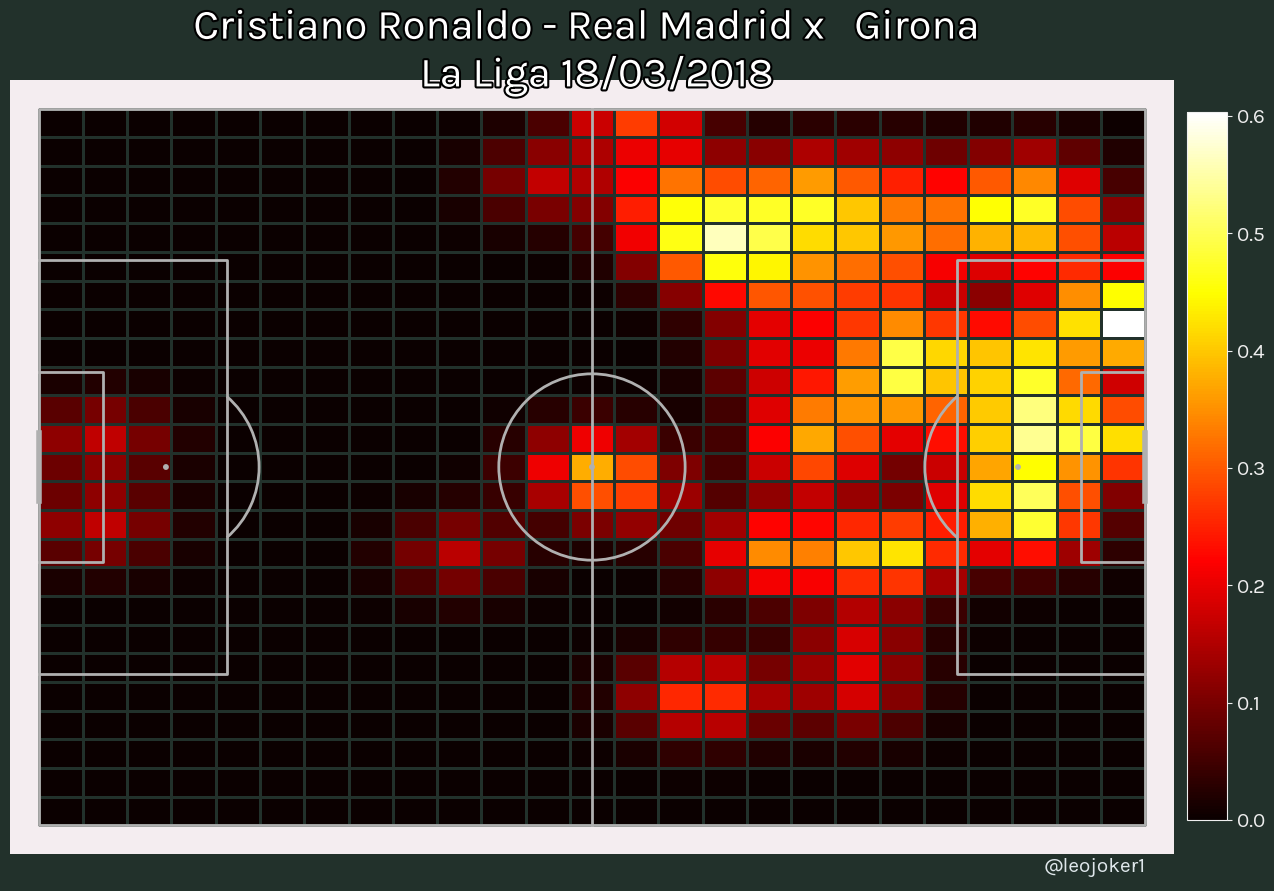

In [118]:
# Definindo o efeito de caminho para o título
path_eff = [path_effects.Stroke(linewidth=3, foreground='black'), path_effects.Normal()]

# Criar o grid para o gráfico
fig, axs = pitch.grid(endnote_height=0.03, endnote_space=0,
                      grid_width=0.88, left=0.025,
                      title_height=0.06, title_space=0,
                      axis=False,
                      grid_height=0.86)
fig.set_facecolor('#22312b')

# plot heatmap
bin_statistic = pitch.bin_statistic(heatmap.x, heatmap.y, statistic='count', bins=(25, 25))
bin_statistic['statistic'] = gaussian_filter(bin_statistic['statistic'], 1)
pcm = pitch.heatmap(bin_statistic, ax=axs['pitch'], cmap='hot', edgecolors='#22312b')

# add colorbar
ax_cbar = fig.add_axes((0.915, 0.093, 0.03, 0.786))
cbar = plt.colorbar(pcm, cax=ax_cbar)
cbar.outline.set_edgecolor('#efefef')
cbar.ax.yaxis.set_tick_params(color='#efefef')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='#efefef')
for label in cbar.ax.get_yticklabels():
    label.set_fontproperties(karla_regular)
    label.set_fontsize(15)

# endnote and title
axs['endnote'].text(1, 0.5, '@leojoker1', va='center', ha='right', fontsize=15,
                    fontproperties=karla_regular, color='#dee6ea')
ax_title = axs['title'].text(0.5, 0.5, texto, color='white',
                             va='center', ha='center', path_effects=path_eff,
                             fontproperties=karla_regular, fontsize=30)

plt.show()

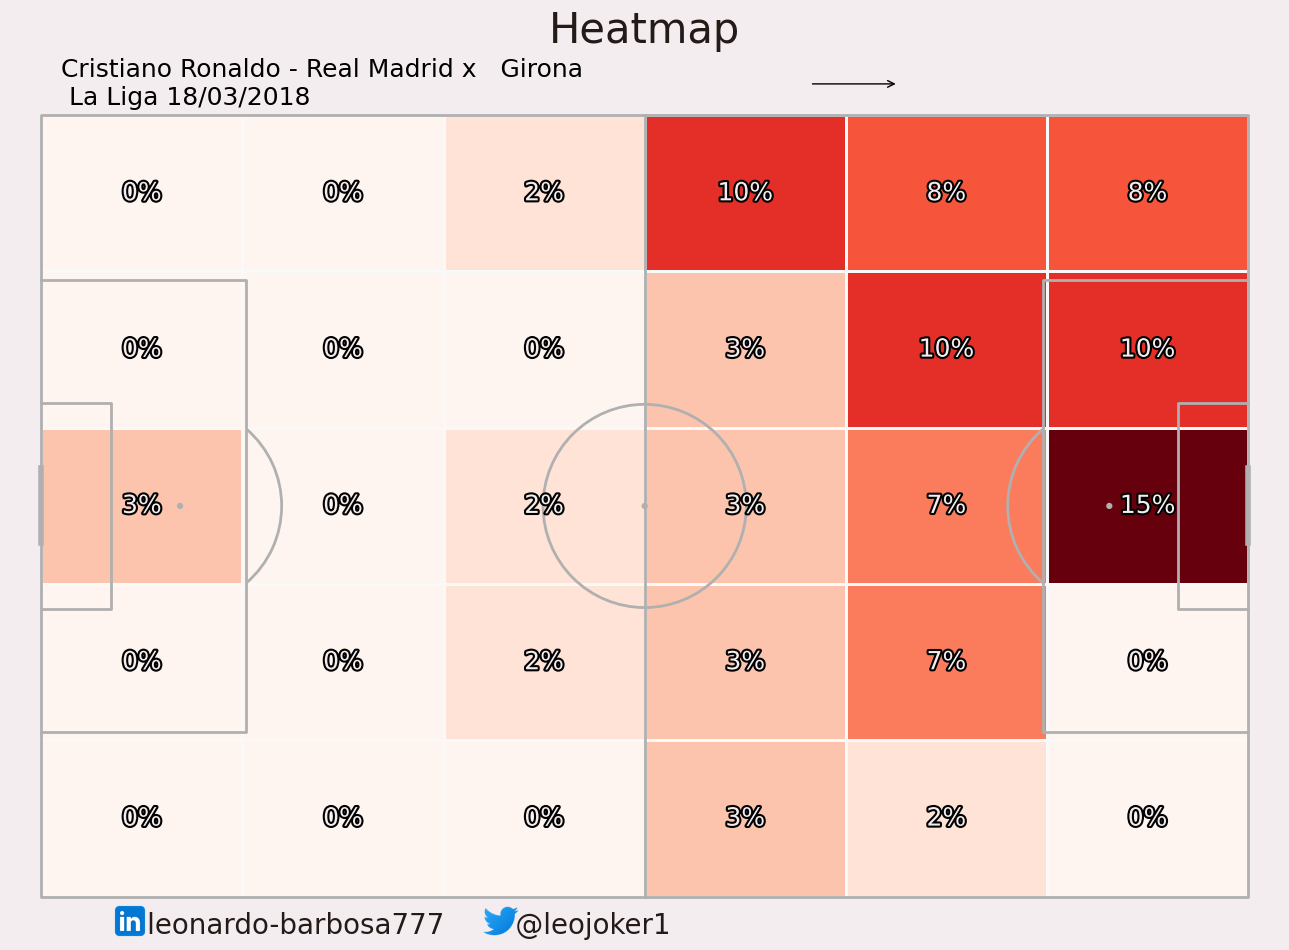

In [119]:
# Definindo o efeito de caminho para o título
path_eff = [path_effects.Stroke(linewidth=3, foreground='black'), path_effects.Normal()]

pitch = Pitch(pitch_type='opta', line_zorder=2, pitch_color='#f4edf0')
fig, ax = pitch.draw(figsize=(16,9))
fig.set_facecolor('#f4edf0')
bin_statistic = pitch.bin_statistic(heatmap.x, heatmap.y, statistic='count', bins=(6, 5), normalize=True)
pitch.heatmap(bin_statistic, ax=ax, cmap='Reds', edgecolor='#f9f9f9')
labels = pitch.label_heatmap(bin_statistic, color='#f4edf0', fontsize=18,
                             ax=ax, ha='center', va='center',
                             str_format='{:.0%}', path_effects=path_eff)


arrow_props = dict(facecolor='black', arrowstyle='->')
ax.annotate('', xy=(0.7, 1), xytext=(0.63, 1),
            arrowprops=arrow_props, fontsize=12, ha='center', va='center', xycoords='axes fraction')


titulo = texto
ax.text(0.04, 1, titulo, fontsize=18, ha='left', va='center', transform=ax.transAxes)


# Adicionar título e créditos à figura
fig.text(x=.5,y=1,s='Heatmap',color='#241B19',fontsize=30,ha='center')
fig.text(x=.15, y=0.01, s='       leonardo-barbosa777        @leojoker1',
 color='#241B19', fontsize=20, ha='left')


# Adicione o ícone do Twitter
twitter_icon_path = "D:/pythonProject/Eventos_Brasileirão/src/images/x.png"  # Substitua pelo caminho correto
twitter_icon = Image.open(twitter_icon_path)
n_size = (40,40)
twitter_icon = twitter_icon.resize(n_size)
fig.figimage(twitter_icon, xo=480, yo=9, origin='upper')


# Adicione o ícone do linkedin
linkedin_icon_path = "D:/pythonProject/Eventos_Brasileirão/src/images/linkedin.png"  # Substitua pelo caminho correto
linkedin_icon = Image.open(linkedin_icon_path)
n_size = (40,40)
linkedin_icon = linkedin_icon.resize(n_size)
fig.figimage(linkedin_icon, xo=110, yo=9, origin='upper')